# Rotevol Tutorial 

In this notebook you will learn how to use rotevol to model the rotational evolution of stars. Rotevol is a forward model that takes evolutionary tracks from YREC and computes the stellar rotation period given the stellar structure and input rotational physics. Because rotevol is a forward model, it does not self-consistenly compute the rotation periods, if you wish to do this, you can use rotation toggles in the YREC code. However, on of the benefits of rotevol is that it is computationally inexpensive, so running large grids with different rotational parameters is more tractable.  
Rotevol works by reading a control file that specifies the rotation parameters and the mass track you wish to compute rotation periods for. An example of the control file is below: 

$CONTROL 

INUMT={0} ! Number of mass tracks \
LSOLID={1} ! T/F flag for rigid rotation \
IWIND={2}  ! 1=No loss 2= Modified Kawaler 3=PMM \
FK={3} ! Parameter (scaling factor) for loss law.  Change to calibrate. \
PMMA={4} ! dM/dt ~ omega^PMMA, PMM wind \
PMMB={5} ! B R^-PMMC ~ omega^PMMB \
PMMC={6} ! Kawaler PMMC = 2 RM PMMC = 0  \
PMMM={7} ! Matt&Pudritz M; dJ/dt~B^4m dM/dt^1-2m.  Matt2012 m=0.22 \
SOLJDOT=1.3000E+30 ! Reference solar dJ/dt, used for constant in PMM \
SOLMDOT=1.2700E+12 ! Reference solar dM/dt, used for constant in PMM \
NUMROT={8} ! Number of rotation cases considered \
PDISK0(1)={9} ! Initial rotation period (days) \
TDISK0(1)={10} ! P = Pdisk enforce for Tdisk (Myr) \
TAUCOUPLE={11} ! Core/envelope coupling timescale (yr); negative=decoupled \
WCRIT=2.836D-5 ! Saturation threshold for loss law (rad/s); 10 omega_sun here \
LROSS={12} ! T/F rossby scaling of omega_crit (iwind=2) or constant(iwind=3) \
LCALSOL=.FALSE. ! If T, set numtrack=1 and calibrate Fk to get solw at solage \
SOLAGE=4.568D9 ! Solar age in Gyr, used for solar calibration \
SOLW=2.86307D-6 ! Solar angular velocity.  25.4d=2.863d-6 rad/s \
$END 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import glob
import scipy.interpolate as interp
import gen_rotgridv3 as gen_rotgrid
import pandas as pd
import matplotlib
import matplotlib.cm as cm
import time

In [2]:
# plot stuff
from cycler import cycler
color_cycle = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
custom_cycler = (cycler(color=color_cycle))

plt.style.use("default")
plt.rcParams["mathtext.default"] = 'rm'

plt.rcParams["font.size"] = 24
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.size"] = 7
plt.rcParams["ytick.minor.size"] = 7
plt.rcParams["xtick.major.size"] = 10
plt.rcParams["ytick.major.size"] = 10
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.labelsize"] = 18
plt.rcParams['axes.labelsize'] = 'small'
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.5
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

In [3]:
#define relevant directories and const variables

rotevol_executable = "run_experiment"
track_dir = "../../Release Paper Sample Case Output/Gyrochrones"
local_rotevol = os.getcwd()

## Case 1 - Solar Mass Model with different rotation physics


This tutorial uses a python wrapper to run rotevol with different cases. 




In [4]:
#define input and output directories: 


master_output_dir = "/tracks/solar_model/"

fname_template = "solar_rot_{0}PMMA"


os.system("mkdir {0}".format(master_output_dir))

#define model grid parameters for control file: 
Lsolid = ["T"]
IWIND = ["3"]
Fk = ["6.5600D0"]
PMMA = ["2.0000D0", "3.0000D0"]
PMMB = ["1.0000D0"]
PMMC = ["0.0000D0"]
PMMM = ["2.2000D-1"]
SOLJDOT = ["1.3000E+30"]
SOLMDOT = ["1.2700E+12"]
NUM_ROT = ["1"]
Prot0 = ["1.0000D0"]
Tdisk = ["5.000D1"]
TauCouple = ["2.0000E+07"]
Ro_scale = ["TRUE"]
Omega_Crit = ["2.687D-5"] 
LROSS = ["T"]
LCalSol = ["FALSE"]
SOLAGE = ["4.568D9"]
SOLW = ["2.86307D-6"] 

# Use tools from gen_rotgrid to generde runfiles and control files: 

grid = np.meshgrid(Lsolid, IWIND, Fk, PMMA, PMMB, PMMC, PMMM, SOLJDOT, SOLMDOT, NUM_ROT, Prot0, Tdisk, TauCouple, Ro_scale, Omega_Crit, LROSS, 
                  LCalSol, SOLAGE, SOLW)
dim = len(grid)
elements = grid[0].size  # Number of elements, any index will do
flat = np.concatenate(grid).ravel()  # Flatten the whole meshgrid
grid = np.reshape(flat, (dim, elements)).T  # Reshape and transpose


for windparam in grid: 
    #generate runfile 
    runfile_params = {"local":local_rotevol,
                 "tracks": track_dir,
                 "output_dir": local_rotevol + master_output_dir,
                 "dat_file":fname_template.format(windparam[3]),
                 "track_file": "rotevolin_m1p05per8p0",
                 "numerics_out": "rotevolin_m1p05per8p0",
                 "rot_track_out": fname_template.format(windparam[3]),
                 "executable_name": rotevol_executable}

    
    runfile_name = "run_" + fname_template.format(windparam[3])
    
    #generate control file
    controlfile_params = {"INUMT":"1",
               "LSOLID":windparam[0],
               "IWIND":windparam[1],
               "FK":windparam[2],
              "PMMA":windparam[3],
              "PMMB": windparam[4],
              "PMMC": windparam[5],
              "PMMM": windparam[6],
              "NUMROT":"1",
              "PDISK0(1)":windparam[10],
              "TDISK0(1)":windparam[11],
              "TAUCOUPLE":windparam[12],
              "WCRIT":windparam[14],
              "LROSS":windparam[13], 
              "SOLAGE":windparam[17], 
              "SOLW":windparam[18]}

    
    controlfile_name = fname_template.format(windparam[3]) + ".dat"
   
    gen_rotgrid.gen_runfile(runfile_params, runfile_name)
    gen_rotgrid.gen_controlfile(controlfile_params, controlfile_name)
    
    os.system("make -f Makerotwind")
    os.system("mkdir -p {0}".format(runfile_params["output_dir"]))
    
    os.system("./{0}".format(runfile_name)) #runs rotevol for the set of parameters given by windparam

    

Now that those grid points have been run, you can go into the tracks/solar_model directory to see the two solar models. You can use read_rotfiles to easily convert the base rotevol outputs to a numpy or pandas readable format. 

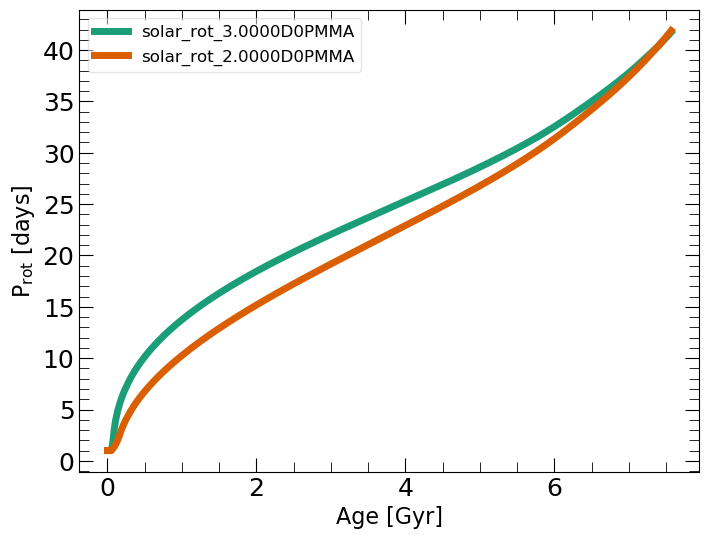

Rotevol Available Columns =  Index(['J', 'K', 'Age(Gyr)', 'L/Lsun', 'R/Rsun', 'LogTeff(K)', 'Mcz(Msun)',
       'Rcz(Rsun)', 'Xcen', 'Itot(cgs)', 'Icz(cgs)', 'Tau(cz)(sec)',
       'HeCore(Msun)', 'Patm(cgs)', 'Mass(Msun)', 'Prot(days)', 'Icore(cgs)',
       'Omega(core)', 'Omega(env)', 'Jtot(cgs)', 'Jcore(cgs)', 'Jenv(cgs)',
       'CentrifugalCorr', 'CoronalB/Bsol', 'dM/dt(Msun/yr)'],
      dtype='object')


In [5]:
rotfiles = glob.glob(local_rotevol + master_output_dir + "*.out")
rotfiles_clean_dir = local_rotevol + master_output_dir + "clean_rotfiles"

fig = plt.figure(figsize = (8, 6))
ax1 = plt.subplot(111)
ax1.set_prop_cycle(custom_cycler)
ax1.set_xlabel("Age [Gyr]", fontsize = 16)
ax1.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 16)

for r in rotfiles:

    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    
    rottrack = np.genfromtxt(rottrack_fname)
    rottrack = pd.DataFrame(rottrack, columns=rotfile_header)
   

    ax1.plot(rottrack["Age(Gyr)"], rottrack['Prot(days)'], linewidth = 5, label = rottrack_fname.split("/")[-1])
    
ax1.legend()
plt.show()
print("Rotevol Available Columns = ", rottrack.columns)

Note that often times one will want to calibrate a rotation model so that it reproduces the solar angular velocity at solar age. To do this, one can run a solar mass track through rotevol and vary the Fk parameter until the models reproduce the solar angular velocity. 

## Case 2 - Model Grid with one set of rotation physics

Another case for rotevol involves running model grids for stars of different masses or composition. This process is simlar to the above case, but reads in a number of different mass tracks generated by YREC. 

In [6]:
#define input and output directories: 

fname_template = "{0}"

#define model grid parameters for control file: 
Lsolid = ["T"]
IWIND = ["3"]
Fk = ["6.5600D0"]
PMMA = ["2.0000D0"]
PMMB = ["1.0000D0"]
PMMC = ["0.0000D0"]
PMMM = ["2.2000D-1"]
SOLJDOT = ["1.3000E+30"]
SOLMDOT = ["1.2700E+12"]
NUM_ROT = ["1"]
Prot0 = ["1.0000D0"]
Tdisk = ["5.000D1"]
TauCouple = ["2.0000E+07"]
Ro_scale = ["TRUE"]
Omega_Crit = ["2.687D-5"] 
LROSS = ["T"]
LCalSol = ["FALSE"]
SOLAGE = ["4.568D9"]
SOLW = ["2.86307D-6"] 

master_output_dir = "/tracks/2.0000D0PMMA_1.0000D0PMMB_2.2000D-1PMMM/"

# Use tools from gen_rotgrid to generde runfiles and control files: 

grid = np.meshgrid(Lsolid, IWIND, Fk, PMMA, PMMB, PMMC, PMMM, SOLJDOT, SOLMDOT, NUM_ROT, Prot0, Tdisk, TauCouple, Ro_scale, Omega_Crit, LROSS, 
                  LCalSol, SOLAGE, SOLW)
dim = len(grid)
elements = grid[0].size  # Number of elements, any index will do
flat = np.concatenate(grid).ravel()  # Flatten the whole meshgrid
grid = np.reshape(flat, (dim, elements)).T  # Reshape and transpose


for windparam in grid: 
    #generate runfile 
    tracks = sorted(glob.glob(track_dir + "/rotevolin*.track"))
    for t in tracks: 
        track_name = t.split("/")[-1].split(".track")[0]
        
        runfile_params = {"local":local_rotevol,
                     "tracks": track_dir,
                     "output_dir": local_rotevol + master_output_dir,
                     "dat_file":fname_template.format(track_name),
                     "track_file": track_name,
                     "numerics_out": track_name + "_num",
                     "rot_track_out": track_name + "_rot",
                     "executable_name": rotevol_executable}

        
        runfile_name = "run_" + track_name

        #generate control file
        controlfile_params = {"INUMT":"1",
                   "LSOLID":windparam[0],
                   "IWIND":windparam[1],
                   "FK":windparam[2],
                  "PMMA":windparam[3],
                  "PMMB": windparam[4],
                  "PMMC": windparam[5],
                  "PMMM": windparam[6],
                  "NUMROT":"1",
                  "PDISK0(1)":windparam[10],
                  "TDISK0(1)":windparam[11],
                  "TAUCOUPLE":windparam[12],
                  "WCRIT":windparam[14],
                  "LROSS":windparam[13], 
                  "SOLAGE":windparam[17], 
                  "SOLW":windparam[18]}

        
        controlfile_name = track_name + ".dat"

        gen_rotgrid.gen_runfile(runfile_params, runfile_name)
        gen_rotgrid.gen_controlfile(controlfile_params, controlfile_name)

        os.system("make -f Makerotwind")
        os.system("mkdir -p {0}".format(runfile_params["output_dir"]))

        os.system("./{0}".format(runfile_name)) #runs rotevol for the set of parameters given by windparam


Using the same functionallity as the solar model case, we can read in the mass grid: 

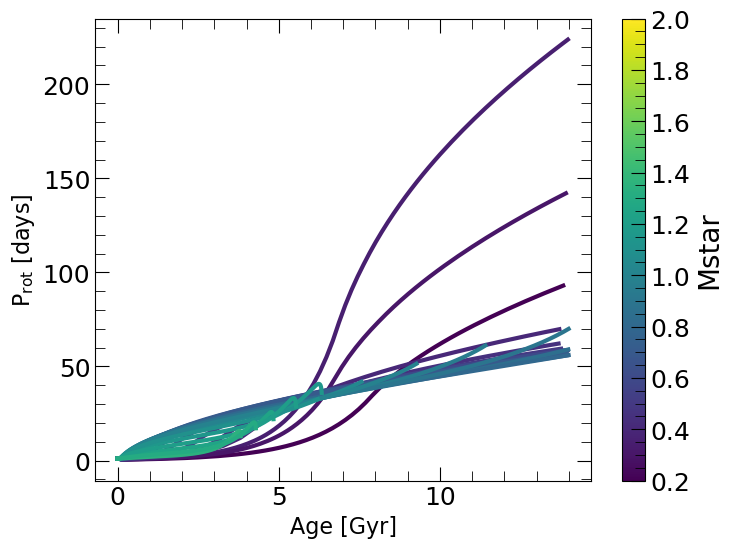

Rotevol Available Columns =  Index(['J', 'K', 'Age(Gyr)', 'L/Lsun', 'R/Rsun', 'LogTeff(K)', 'Mcz(Msun)',
       'Rcz(Rsun)', 'Xcen', 'Itot(cgs)', 'Icz(cgs)', 'Tau(cz)(sec)',
       'HeCore(Msun)', 'Patm(cgs)', 'Mass(Msun)', 'Prot(days)', 'Icore(cgs)',
       'Omega(core)', 'Omega(env)', 'Jtot(cgs)', 'Jcore(cgs)', 'Jenv(cgs)',
       'CentrifugalCorr', 'CoronalB/Bsol', 'dM/dt(Msun/yr)'],
      dtype='object')


In [7]:
rotfiles = sorted(glob.glob(local_rotevol + master_output_dir + "*.out"))
rotfiles_clean_dir = local_rotevol + master_output_dir + "clean_rotfiles"

fig = plt.figure(figsize = (8, 6))
ax1 = plt.subplot(111)
ax1.set_prop_cycle(custom_cycler)
norm = matplotlib.colors.Normalize(vmin = 0.2, vmax = 2.0, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")

ax1.set_xlabel("Age [Gyr]", fontsize = 16)
ax1.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 16)


for r in rotfiles:
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    if rottrack_fname == '':
        continue
    mstar = rottrack_fname.split("_m")[1].split("per")[0]
    mstar = float(mstar.replace("p", "."))
    
    
    rottrack = np.genfromtxt(rottrack_fname)
    rottrack = pd.DataFrame(rottrack, columns=rotfile_header)
   

    sc = ax1.plot(rottrack["Age(Gyr)"], rottrack['Prot(days)'], linewidth = 3, c = mapper.to_rgba(mstar))
    
plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax1, label = "Mstar")

plt.show()
print("Rotevol Available Columns = ", rottrack.columns)

To run model grids for a number of different masses and rotational parameters, just incluse more parameters in the param arrays above. 

## Comparison to Full Rotation Models 

In this section we compare the outputs and computation time of full YREC evolution runs including rotation physics and forwrad modelling the rotational evolution with rotevol.The full rotation models are initialized with a disk-locking time of 10Myr and mass-dependent initial rotation periods according to Somers + (2017). 

In [36]:
def p0(mstar):
    if mstar > 0.4:
        pdisk = 8.0 
    if mstar <= 0.4:
        lnpdisk = 3.82*mstar - 0.62
        pdisk = (10**lnpdisk)
        pdisk = pdisk
    return pdisk



In [37]:
solid_rotmodels = sorted(glob.glob(track_dir + "/Gyro*solid.track"))
input_models = sorted(glob.glob(track_dir + "/rotevolin*.track"))
print(input_models)
#define input and output directories: 
master_output_dir = "/tracks/comparisons/solidbody"

fname_template = "{0}"

rotevol_executable = "run_experiment"

#define model grid parameters for control file: 
Lsolid = [".TRUE."]
IWIND = ["3"]
Fk = ["7.500D0"]
PMMA = ["2.0000D0"]
PMMB = ["1.0000D0"]
PMMC = ["0.0000D0"]
PMMM = ["2.2000D-1"]
SOLJDOT = ["1.3200E+30"]
SOLMDOT = ["1.2700E+12"]
NUM_ROT = ["1"]
Prot0 = ["1.0000D0"]
Tdisk = ["1.0000D1"]
TauCouple = ["2.0000E+07"]
Ro_scale = [".TRUE."]
Omega_Crit = ["2.83D-5"] 
LROSS = [".TRUE."]
LCalSol = [".FALSE."]
SOLAGE = ["4.568D8"]
SOLW = [ "2.83D-6"]  # matches the full YREC run value



grid = np.meshgrid(Lsolid, IWIND, Fk, PMMA, PMMB, PMMC, PMMM, SOLJDOT, SOLMDOT, NUM_ROT, Prot0, Tdisk, TauCouple, 
                   Ro_scale, Omega_Crit, LROSS, LCalSol, SOLAGE, SOLW)
dim = len(grid)
elements = grid[0].size  # Number of elements, any index will do
flat = np.concatenate(grid).ravel()  # Flatten the whole meshgrid
grid = np.reshape(flat, (dim, elements)).T  # Reshape and transpose


for windparam in grid: 
    #generate runfile 
    
    for t in input_models: 
        track_name = t.split("/")[-1].split(".track")[0]
        
        mstar = t.split("_m")[1].split("per")[0]
        mstar = float(mstar.replace("p", "."))
        
        if mstar > 1.4:
            evol_track_dat, evol_out = gen_rotgrid.read_trackfile(track_tmp.format(int(mstar)), "evol_tracks/clean_files")
            tdisk = evol_track_dat["Age_gyr"].iloc[0] * 1e3 #conversion to Myr
            prot_0 = evol_track_dat["Prot_sur_d"].iloc[0]
            
        else:
            
            tdisk = windparam[11]
            prot_0 = p0(mstar)
        
        
            
        
        
        
        runfile_params = {"local":local_rotevol,
                     "tracks": track_dir,
                     "output_dir": local_rotevol + master_output_dir,
                     "dat_file":fname_template.format(track_name),
                     "track_file": track_name,
                     "numerics_out": track_name + "_num",
                     "rot_track_out": track_name + "_rot",
                     "executable_name": rotevol_executable}
        
        
        runfile_name = "run_" + track_name

        #generate control file
        controlfile_params = {"INUMT":"1",
                   "LSOLID":windparam[0],
                   "IWIND":windparam[1],
                   "FK":windparam[2],
                  "PMMA":windparam[3],
                  "PMMB": windparam[4],
                  "PMMC": windparam[5],
                  "PMMM": windparam[6],
                  "NUMROT":"1",
                  "PDISK0(1)":prot_0,
                  "TDISK0(1)":tdisk,
                  "TAUCOUPLE":windparam[12],
                  "WCRIT":windparam[14],
                  "LROSS":windparam[13],
                  "SOLAGE":windparam[17], 
                  "SOLW":windparam[18]}

        
        controlfile_name = track_name + ".dat"
        

        gen_rotgrid.gen_runfile(runfile_params, runfile_name)
        gen_rotgrid.gen_controlfile(controlfile_params, controlfile_name)

        os.system("make -f Makerotwind")
        os.system("mkdir -p {0}".format(runfile_params["output_dir"]))
        start = time.time()
        os.system('./{0}'.format(runfile_name)) #runs rotevol for the set of parameters given by windparam
        end = time.time()
        print("Rotevol runtime: {:.3f}".format(end - start))
        



['../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p25per2p2.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p2per1p4.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p35per5p2.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p3per3p4.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p45per8p0.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p4per8p1.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p55per8p0.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p5per8p0.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p65per8p0.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p6per8p0.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p75per8p0.track', '../../Release Paper Sample Case Output/Gyrochrones/rotevolin_m0p7per8p0.track', '../../Release Paper 

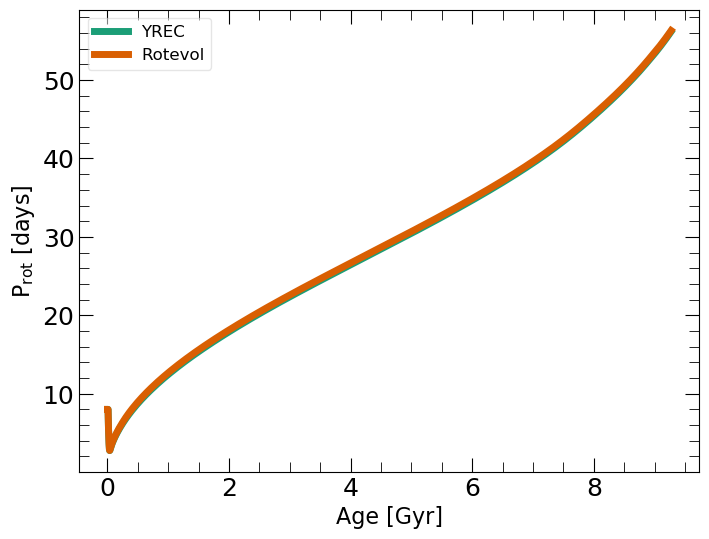

In [38]:
#compare solar models 

rotfiles = sorted(glob.glob(local_rotevol + master_output_dir + "*.out"))
rotfiles_clean_dir = local_rotevol + master_output_dir + "clean_rotfiles"

solar_rotevol = local_rotevol + master_output_dir + "/rotevolin_m1p0per8p0_rot.out"
fig = plt.figure(figsize = (8, 6))
ax1 = plt.subplot(111)
ax1.set_prop_cycle(custom_cycler)
ax1.set_xlabel("Age [Gyr]", fontsize = 16)
ax1.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 16)

rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(solar_rotevol, rotfiles_clean_dir)



YREC_df, YREC_out = gen_rotgrid.read_trackfile(track_dir + "/Gyrochrone_m1p0per8p0_solid.track", "evol_tracks/clean_files")


ax1.plot(YREC_df["Age_gyr"], YREC_df['Prot_sur_d'], linewidth = 5, label = "YREC")
ax1.plot(rottrack["Age(Gyr)"], rottrack['Prot(days)'], linewidth = 5, label = "Rotevol")

ax1.legend()
plt.show()


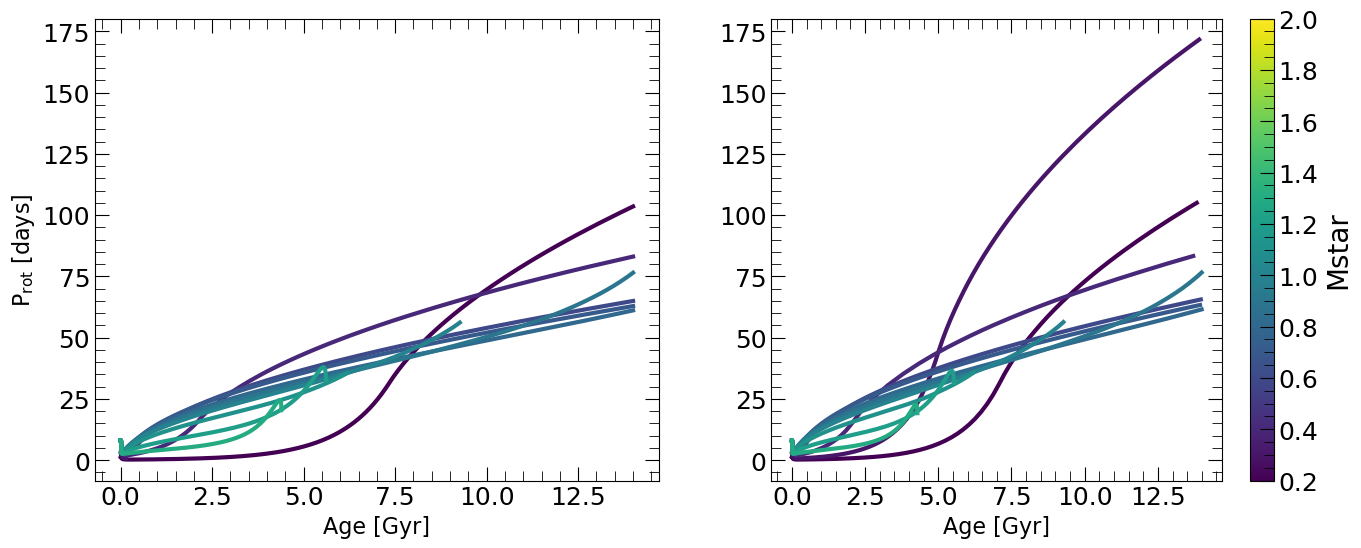

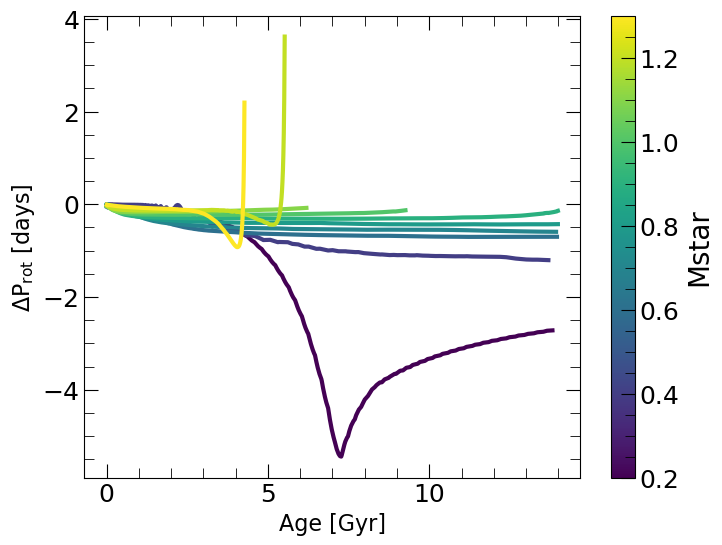

In [46]:
#compare all models 
rotfiles = sorted(glob.glob(local_rotevol + master_output_dir + "/rotevolin*.out"))
rotfiles_clean_dir = local_rotevol + master_output_dir + "clean_rotfiles"
track_tmp = track_dir + "/Gyrochrone_{0}_solid.track"

fig = plt.figure(figsize = (16,6))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, sharey = ax1, sharex = ax1)
ax1.set_prop_cycle(custom_cycler)
ax2.set_prop_cycle(custom_cycler)

norm = matplotlib.colors.Normalize(vmin = 0.2, vmax = 2.0, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")

ax1.set_xlabel("Age [Gyr]", fontsize = 16)
ax2.set_xlabel("Age [Gyr]", fontsize = 16)

ax1.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 16)

for r in rotfiles: 
    
   
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    
    
    mstar = r.split("_m")[1].split("per")[0]
    if mstar[-1] == '5':
        continue
    mstar = float(mstar.replace("p", "."))
    
    
    
    track = track_tmp.format(r.split("rotevolin_")[1].split("_rot.out")[0])
    
    try:
        YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
    except:
        print("YREC track does not exist for m* = {0} msun".format(mstar))
        continue
    
    if rottrack.empty == True:
        continue
    
    ax1.plot(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], 
             linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")
    ax2.plot(rottrack["Age(Gyr)"], rottrack["Prot(days)"], 
            linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")


plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax2, label = "Mstar")
plt.show()


####
fig = plt.figure(figsize = (8,6))
ax1 = plt.subplot(111)

ax1.set_prop_cycle(custom_cycler)


norm = matplotlib.colors.Normalize(vmin = 0.2, vmax = 1.3, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")

ax1.set_xlabel("Age [Gyr]", fontsize = 16)

ax1.set_ylabel(r"$ \Delta P_{rot} \ [days]$", fontsize = 16)

for r in rotfiles: 
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    
    
    mstar = r.split("_m")[1].split("per")[0]
    if mstar[-1] == '5':
        continue
    mstar = float(mstar.replace("p", "."))
    
    track = track_tmp.format(r.split("rotevolin_")[1].split("_rot.out")[0])
    
    try:
        YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
        YREC_df = YREC_df.dropna()
    except:
        print("YREC track does not exist for m* = {0} msun".format(mstar))
        continue
    
    if rottrack.empty == True:
        continue
    
    YREC_prot_interp = interp.interp1d(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], bounds_error=False, fill_value=np.nan) 
    
#    
    rottrack = rottrack.dropna()
    
    rotevol_prot_interp = interp.interp1d(rottrack["Age(Gyr)"], rottrack["Prot(days)"], bounds_error=False, fill_value=np.nan) 
    age_array = np.linspace(0, 14, int(1e3))
    
    ax1.plot(age_array, (YREC_prot_interp(age_array) - rotevol_prot_interp(age_array)), 
             linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")


plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax1, label = "Mstar")

Finally we will compare rotevol models and YREC models with core-envelope decoupling.

In [47]:
#core-envelope timescales given as [Mass, CE time (Myr)]

CE_times = np.array([[0.4, 2444], 
           [0.5, 1360], 
           [0.6, 575], 
           [0.7, 265], 
           [0.8, 158], 
           [0.9, 125], 
           [1.0, 64.3], 
           [1.1, 30.0], 
           [1.2, 11.4], 
           [1.3, 6.19]])

CE_interp = interp.interp1d(CE_times[:,0], CE_times[:,1], bounds_error = False)

In [48]:
full_rotmodels = sorted(glob.glob(track_dir + "/Gyrochrone*0.track"))


#define input and output directories: 
master_output_dir = "/tracks/comparisons/nonsolidbody"
fname_template = "{0}"



#define model grid parameters for control file: 
Lsolid = [".FALSE"]
IWIND = ["3"]
Fk = ["1.08000D1"]
PMMA = ["2.0000D0"]
PMMB = ["1.0000D0"]
PMMC = ["0.0000D0"]
PMMM = ["2.2000D-1"]
SOLJDOT = ["1.3000E+30"]
SOLMDOT = ["1.2700E+12"]
NUM_ROT = ["1"]
Prot0 = ["1.0000D0"]
Tdisk = ["1.000D1"]
TauCouple = ["2.0000E+07"]
Ro_scale = ["TRUE"]
Omega_Crit = ["2.83D-5"]
LROSS = [".TRUE."]
LCalSol = [".FALSE."]
SOLAGE = ["4.568D9"]
SOLW = ["2.83D-6"] 


grid = np.meshgrid(Lsolid, IWIND, Fk, PMMA, PMMB, PMMC, PMMM, SOLJDOT, SOLMDOT, NUM_ROT, Prot0, Tdisk, TauCouple, Ro_scale, Omega_Crit, LROSS, 
                  LCalSol, SOLAGE, SOLW)
dim = len(grid)
elements = grid[0].size  # Number of elements, any index will do
flat = np.concatenate(grid).ravel()  # Flatten the whole meshgrid
grid = np.reshape(flat, (dim, elements)).T  # Reshape and transpose


for windparam in grid: 
    #generate runfile 
    
    for t in input_models: 
        
        track_name = t.split("/")[-1].split(".track")[0]
        mstar = t.split("_m")[1].split("per")[0]
        mstar = float(mstar.replace("p", "."))
        
        
            
        
        if mstar < 0.4:
            Lsolid = "T" # doesn't matter no core-envelope recoupling for these stars
            Tau_couple = 1
            tdisk = windparam[11]
            prot_0 = p0(mstar)
        if mstar >= 0.4:
            Tau_couple = CE_interp(mstar) * 1e6 #Myr conversion
            Lsolid = "F"
            tdisk = windparam[11]
            prot_0 = p0(mstar)
        if mstar >= 1.4:
            continue
           
        
        
        runfile_params = {"local":local_rotevol,
                     "tracks": track_dir,
                     "output_dir": local_rotevol + master_output_dir,
                     "dat_file":fname_template.format(track_name),
                     "track_file": track_name,
                     "numerics_out": track_name + "_num",
                     "rot_track_out": track_name + "_rot",
                     "executable_name": rotevol_executable}

        
        runfile_name = "run_" + track_name

        #generate control file
        controlfile_params = {"INUMT":"1",
                   "LSOLID":Lsolid,
                   "IWIND":windparam[1],
                   "FK":windparam[2],
                  "PMMA":windparam[3],
                  "PMMB": windparam[4],
                  "PMMC": windparam[5],
                  "PMMM": windparam[6],
                  "NUMROT":"1",
                  "PDISK0(1)":prot_0,
                  "TDISK0(1)":tdisk,
                  "TAUCOUPLE":Tau_couple,
                  "WCRIT":windparam[14],
                  "LROSS":windparam[13], 
                  "SOLAGE":windparam[17], 
                  "SOLW":windparam[18]}

        
        controlfile_name = track_name + ".dat"
        

        gen_rotgrid.gen_runfile(runfile_params, runfile_name)
        gen_rotgrid.gen_controlfile(controlfile_params, controlfile_name)

        os.system("make -f Makerotwind")
        os.system("mkdir -p {0}".format(runfile_params["output_dir"]))
        start = time.time()
        os.system('./{0}'.format(runfile_name)) #runs rotevol for the set of parameters given by windparam
        end = time.time()
        print("Rotevol runtime: {:.3f}".format(end - start))
        



Rotevol runtime: 0.106
Rotevol runtime: 0.106
Rotevol runtime: 0.121
Rotevol runtime: 0.114
Rotevol runtime: 0.117
Rotevol runtime: 0.091
Rotevol runtime: 0.122
Rotevol runtime: 0.124
Rotevol runtime: 0.119
Rotevol runtime: 0.123
Rotevol runtime: 0.121
Rotevol runtime: 0.124
Rotevol runtime: 0.133
Rotevol runtime: 0.126
Rotevol runtime: 0.134
Rotevol runtime: 0.140
Rotevol runtime: 0.131
Rotevol runtime: 0.133
Rotevol runtime: 0.142
Rotevol runtime: 0.137
Rotevol runtime: 0.142
Rotevol runtime: 0.158
Rotevol runtime: 0.134
Rotevol runtime: 0.148


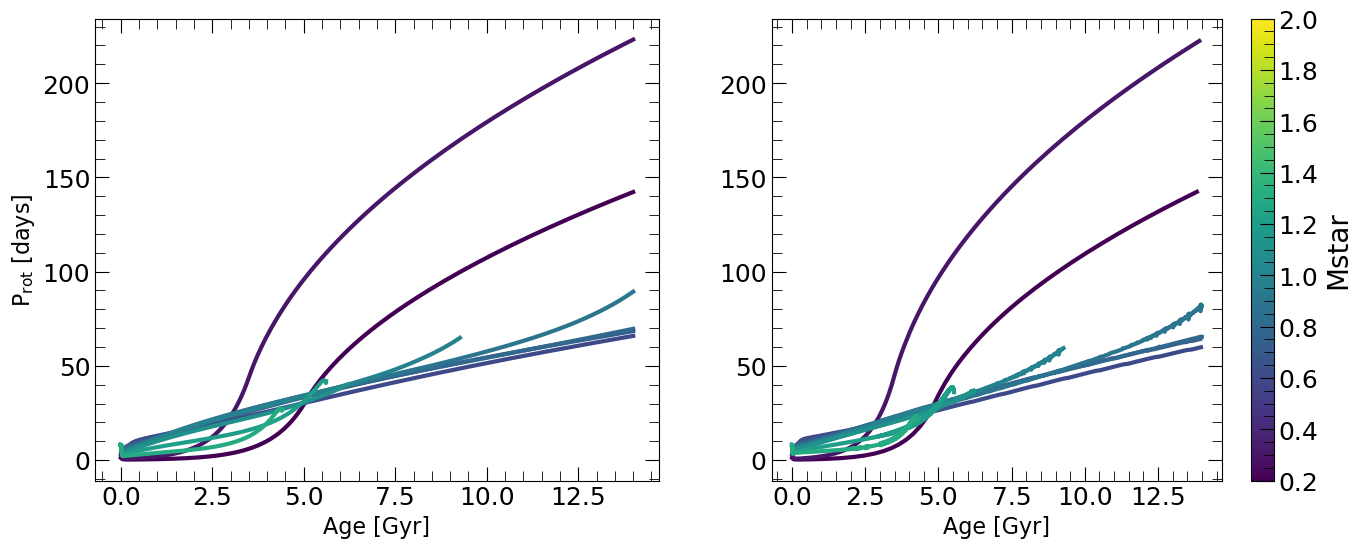

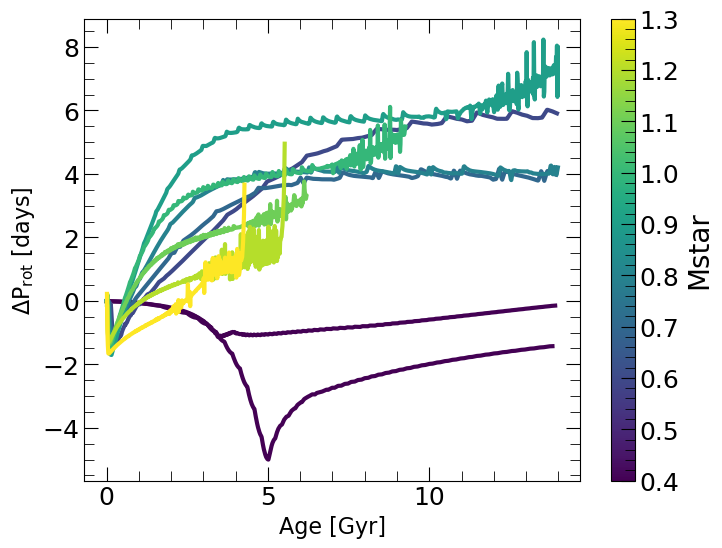

In [49]:

#compare all models 
rotfiles = sorted(glob.glob(local_rotevol + master_output_dir + "/rotevolin*.out"))
rotfiles_clean_dir = local_rotevol + master_output_dir + "clean_rotfiles"
track_tmp = track_dir + "/Gyrochrone{0}.track"

fig = plt.figure(figsize = (16,6))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, sharey = ax1, sharex = ax1)
ax1.set_prop_cycle(custom_cycler)
ax2.set_prop_cycle(custom_cycler)

norm = matplotlib.colors.Normalize(vmin = 0.2, vmax = 2.0, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")

ax1.set_xlabel("Age [Gyr]", fontsize = 16)
ax2.set_xlabel("Age [Gyr]", fontsize = 16)

ax1.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 16)

for r in rotfiles: 
    
   
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    
    
    mstar = r.split("_m")[1].split("per")[0]
    
    if mstar[-1] == '5':
        continue
    mstar = float(mstar.replace("p", "."))
    
    track = track_tmp.format(r.split("rotevolin")[1].split("_rot.out")[0])
    
    try:
        YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
    except:
        print("YREC track does not exist for m* = {0} msun".format(mstar))
        continue
    

    
    ax1.plot(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], 
             linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")
    ax2.plot(rottrack["Age(Gyr)"], rottrack["Prot(days)"], 
            linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")


plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax2, label = "Mstar")
plt.show()
####
fig = plt.figure(figsize = (8,6))
ax1 = plt.subplot(111)

ax1.set_prop_cycle(custom_cycler)


norm = matplotlib.colors.Normalize(vmin = 0.4, vmax = 1.3, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")

ax1.set_xlabel("Age [Gyr]", fontsize = 16)

ax1.set_ylabel(r"$ \Delta P_{rot} \ [days]$", fontsize = 16)

for r in rotfiles: 
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    
    
    mstar = r.split("_m")[1].split("per")[0]
    if mstar[-1] == '5':
        
        continue
    
    mstar = float(mstar.replace("p", "."))
    
    track = track_tmp.format(r.split("rotevolin")[1].split("_rot.out")[0])
    
    try:
        YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
        YREC_df = YREC_df.dropna()
    except:
        print("YREC track does not exist for m* = {0} msun".format(mstar))
        continue
    
    
    
    YREC_prot_interp = interp.interp1d(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], bounds_error=False, fill_value=np.nan) 
    
#    
    rottrack = rottrack.dropna()
    
    rotevol_prot_interp = interp.interp1d(rottrack["Age(Gyr)"], rottrack["Prot(days)"], bounds_error=False, fill_value=np.nan) 
    age_array = np.linspace(0, 14, int(1e3))
    
    ax1.plot(age_array, (YREC_prot_interp(age_array) - rotevol_prot_interp(age_array)), 
             linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")


plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax1, label = "Mstar")

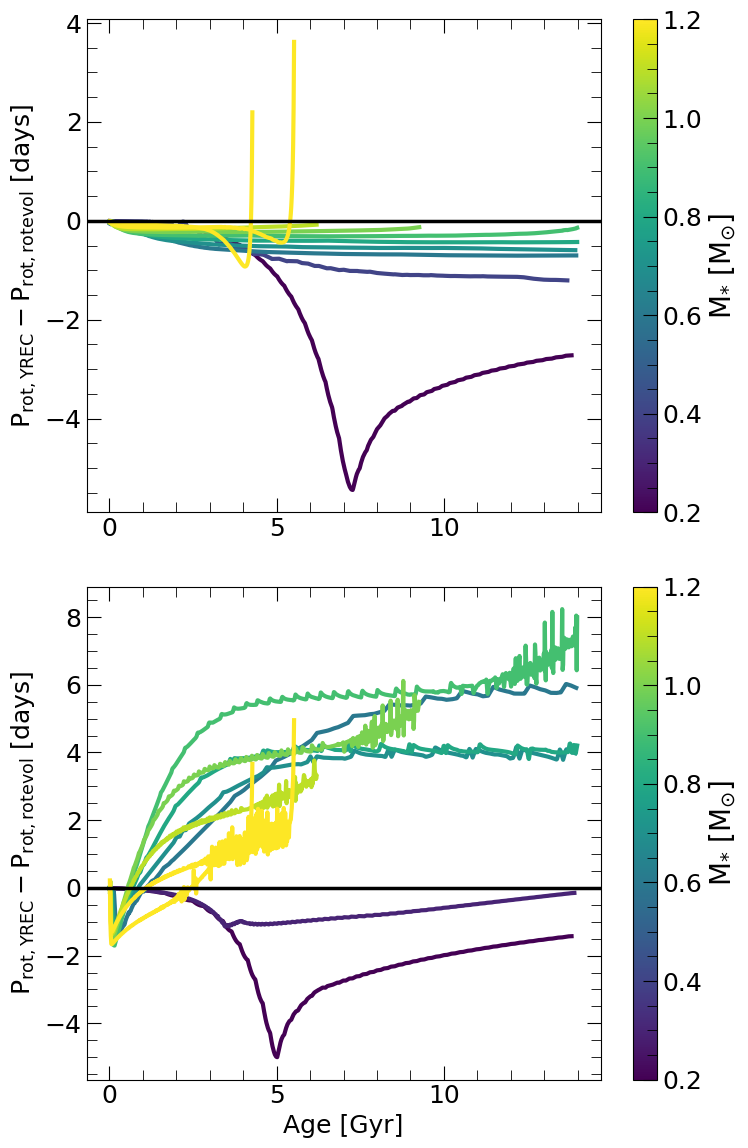

In [53]:
track_tmpsolid = track_dir + "/Gyrochrone{0}_solid.track"
track_tmpnonsolid = track_dir + "/Gyrochrone{0}.track"


rotfiles_solid = sorted(glob.glob(local_rotevol + '/tracks/comparisons/solidbody' + "/rotevolin*.out"))
rotfiles_nonsolid = sorted(glob.glob(local_rotevol + '/tracks/comparisons/nonsolidbody' + "/rotevolin*.out"))

fig = plt.figure(figsize = (8,12))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212, sharex = ax1)
norm = matplotlib.colors.Normalize(vmin = 0.2, vmax = 1.2, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")


ax2.set_xlabel("Age [Gyr]", fontsize = 18)
ax1.set_ylabel(r"$P_{rot, YREC} - P_{rot, rotevol} \ [days]$", fontsize = 18)
ax2.set_ylabel(r"$P_{rot, YREC} - P_{rot, rotevol} \ [days]$", fontsize = 18)

for r in rotfiles_solid: 
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    mstar = r.split("_m")[1].split("per")[0]
    if mstar[-1] == '5':
        
        continue
    mstar = float(mstar.replace("p", "."))
    
    track = track_tmpsolid.format(r.split("rotevolin")[1].split("_rot.out")[0])
    
    try:
        YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
        YREC_prot_interp = interp.interp1d(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], bounds_error=False, fill_value=np.nan) 
    except:
        print("YREC track does not exist for m* = {0} msun".format(mstar))
        continue
#    
    rottrack = rottrack.dropna()
    
    rotevol_prot_interp = interp.interp1d(rottrack["Age(Gyr)"], rottrack["Prot(days)"], bounds_error=False, fill_value=np.nan) 
    age_array = np.linspace(0, 14, int(1e3))
    
    ax1.plot(age_array, (YREC_prot_interp(age_array) - rotevol_prot_interp(age_array)), 
             linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")
    
ax1.axhline(y = 0, color = "k")


rotfiles = sorted(glob.glob("tracks/CE_models/M*rotin*"))

track_tmp1 = track_dir + "/M{:05d}_FeH0p0_gyrochrone.track"


for r in rotfiles_nonsolid: 
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    mstar = r.split("_m")[1].split("per")[0]
    if mstar[-1] == '5':
        
        continue
    mstar = float(mstar.replace("p", "."))
    
    track = track_tmpnonsolid.format(r.split("rotevolin")[1].split("_rot.out")[0])
    
   
    try:
        YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
        YREC_prot_interp = interp.interp1d(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], bounds_error=False, fill_value=np.nan) 
    except:
        print("YREC track does not exist for m* = {0} msun".format(mstar))
        continue
#    
    rottrack = rottrack.dropna()
    
    rotevol_prot_interp = interp.interp1d(rottrack["Age(Gyr)"], rottrack["Prot(days)"], bounds_error=False, fill_value=np.nan) 
    age_array = np.linspace(0, 14, int(1e3))
    
    ax2.plot(age_array, (YREC_prot_interp(age_array) - rotevol_prot_interp(age_array)), 
             linewidth = 3, color = mapper.to_rgba(mstar), linestyle = "solid")
    
ax2.axhline(y = 0, color = "k")

plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax2, label = r"$M_{*} \ [M_{\odot}]$")
plt.colorbar(cm.ScalarMappable(norm = norm, cmap = "viridis"), ax = ax1, label = r"$M_{*} \ [M_{\odot}]$")
plt.tight_layout()
plt.savefig("full_rotevol_comparison.pdf", bbox_inches = "tight")

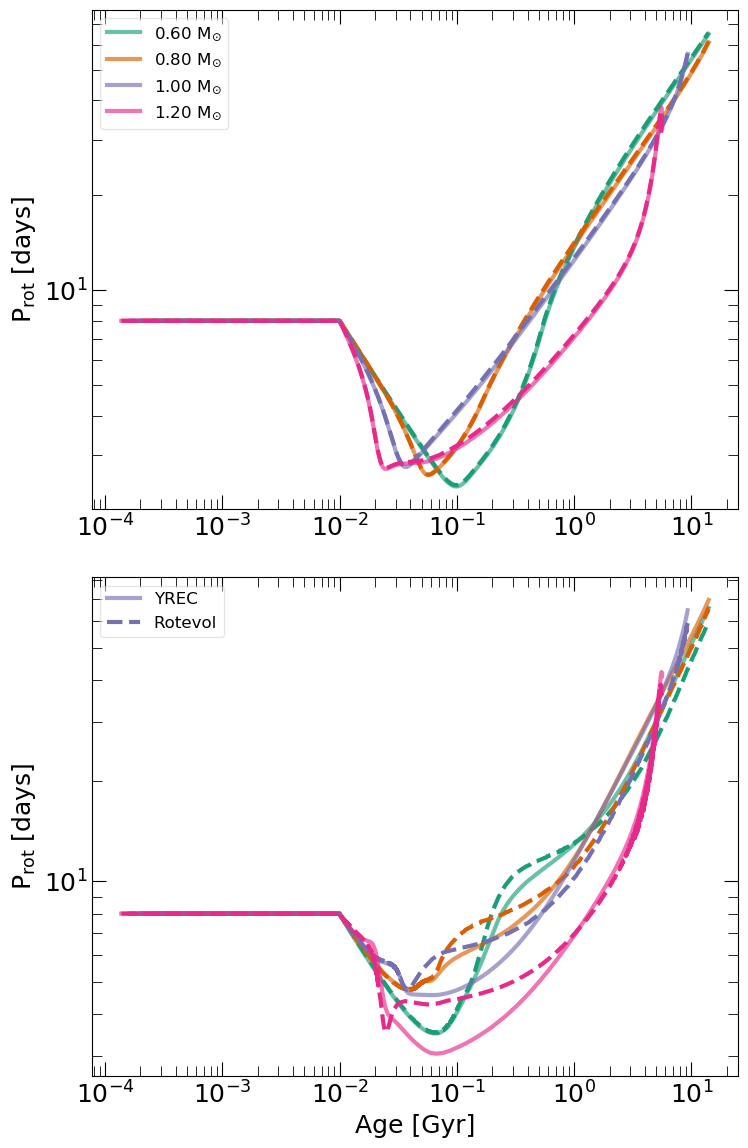

In [54]:
track_tmpsolid = track_dir + "/Gyrochrone{0}_solid.track"
track_tmpnonsolid = track_dir + "/Gyrochrone{0}.track"


rotfiles_solid = sorted(glob.glob(local_rotevol + '/tracks/comparisons/solidbody' + "/rotevolin*.out"))
rotfiles_nonsolid = sorted(glob.glob(local_rotevol + '/tracks/comparisons/nonsolidbody' + "/rotevolin*.out"))

fig = plt.figure(figsize = (8,12))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212, sharex = ax1)
norm = matplotlib.colors.Normalize(vmin = 0.2, vmax = 1.2, clip = True)
mapper = cm.ScalarMappable(norm = norm, cmap = "viridis")

ax1.set_prop_cycle(custom_cycler)
ax2.set_prop_cycle(custom_cycler)

ax2.set_xlabel("Age [Gyr]", fontsize = 18)
ax1.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 18)
ax2.set_ylabel(r"$P_{rot} \ [days]$", fontsize = 18)
plotm = [0.6, 0.8, 1.0, 1.2]

i = 0

for r in rotfiles_solid: 
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    mstar = r.split("_m")[1].split("per")[0]
    mstar = float(mstar.replace("p", "."))
    
    if mstar in plotm:
        pass
    else:
        continue
    
    track = track_tmpsolid.format(r.split("rotevolin")[1].split("_rot.out")[0])
    
    
    YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
    
    rottrack = rottrack.dropna()

    
    ax1.plot(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], 
             linewidth = 3, linestyle = "solid", alpha = 0.65,  c = color_cycle[i], 
            label = r"${:.2f}$".format(mstar) +r"$ \ M_{\odot}$" )
    ax1.plot(rottrack["Age(Gyr)"], rottrack["Prot(days)"], 
             linewidth = 3, linestyle = "dashed",  c = color_cycle[i])
    

    i +=1 

i = 0

for r in rotfiles_nonsolid: 
    
    rottrack_fname, rotfile_header, rottrack = gen_rotgrid.read_rotfile(r, rotfiles_clean_dir)
    mstar = r.split("_m")[1].split("per")[0]
    mstar = float(mstar.replace("p", "."))
    
    if mstar in plotm:
        pass
    else:
        continue
    
    track = track_tmpnonsolid.format(r.split("rotevolin")[1].split("_rot.out")[0])
    
    
    YREC_df, YREC_out = gen_rotgrid.read_trackfile(track, "evol_tracks/clean_files")
    
    rottrack = rottrack.dropna()

    if mstar == 1.0:
        ax2.plot(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], 
                 linewidth = 3, linestyle = "solid", alpha = 0.65,  c = color_cycle[i], 
                label = "YREC" )
        ax2.plot(rottrack["Age(Gyr)"], rottrack["Prot(days)"], 
                 linewidth = 3, linestyle = "dashed",  c = color_cycle[i], 
                label = "Rotevol")
    else:
        ax2.plot(YREC_df["Age_gyr"], YREC_df["Prot_sur_d"], 
                 linewidth = 3, linestyle = "solid", alpha = 0.65,  c = color_cycle[i], 
                )
        ax2.plot(rottrack["Age(Gyr)"], rottrack["Prot(days)"], 
                 linewidth = 3, linestyle = "dashed",  c = color_cycle[i], 
                )
        
    i +=1 


    ax1.semilogy()
ax1.semilogx()
ax2.semilogy()
ax2.semilogx()
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.savefig("full_rotevol_comparison.pdf", bbox_inches = "tight")